# Conformal uncertainty quantification on graphs and structures

Point predictions on graphs and combinatorial objects are rarely enough: which community a node belongs
to, which entity completes a knowledge-graph fact, which ranking a user prefers, which nodes a new node
will link to. This notebook builds calibrated set-valued predictions for all of these with split
conformal prediction, which turns any model into one that emits a set guaranteed to contain the truth
with a chosen probability, distribution-free and without assuming the model is correct.

The catch on graphs is exchangeability, the single condition conformal coverage rests on. We make it
precise, identify the graph problems where it holds, and then build four predictors on mixle:
conformal sets over combinatorial structures, transductive node-label sets, link-prediction neighbor
sets, and knowledge-graph tail sets.

## The one condition: exchangeability

Split conformal calibrates a nonconformity score on held-out data and reads off a quantile.

Theorem (split-conformal coverage). Let $s_1,\dots,s_n$ be calibration nonconformity scores and
$s_{n+1}$ a test score, and suppose the $n+1$ scores are exchangeable (their joint law is invariant to
permutation). With the threshold $\hat q$ equal to the $\lceil (n+1)(1-\alpha)\rceil$ smallest
calibration score, the set $\{y : s(x_{n+1},y)\le \hat q\}$ satisfies
$$P\big(y_{n+1}\in \text{set}\big)\ \ge\ 1-\alpha.$$

Proof. By exchangeability the rank of $s_{n+1}$ among the $n+1$ scores is uniform on $\{1,\dots,n+1\}$,
so $s_{n+1}\le \hat q$ with probability $\lceil(n+1)(1-\alpha)\rceil/(n+1)\ge 1-\alpha$. Nothing about
the model enters; a poor model only enlarges the scores, hence the set. $\quad\blacksquare$

On iid tabular data exchangeability is automatic. On graphs it is not, because nodes and edges are
dependent, so each problem below must be set up so that the *scores* are exchangeable:

- Combinatorial structures (rankings, matchings, trees) observed iid: the structure scores are
  exchangeable, so conformal sets over structures are valid.
- Transductive node classification: a fixed graph with labels revealed on a uniformly random subset of
  nodes makes the node scores exchangeable between calibration and test, so node-label sets are valid
  (Zargarbashi et al. 2023; Huang et al. 2023).
- Link prediction and knowledge-graph completion: a uniformly random split of the observed edges or
  triples makes those scores exchangeable, giving coverage marginal over edges or triples (edges are
  not iid, so this is marginal-over-edges coverage, not per-node conditional coverage).

In [1]:
import warnings; warnings.filterwarnings('ignore')
import math
import numpy as np
import matplotlib.pyplot as plt

## 1. Conformal sets over combinatorial structures

A model over a combinatorial object exposes an exact probability for any candidate. mixle's
structure distributions (Plackett-Luce over rankings, Mallows over permutations, and distributions over
matchings and spanning trees) all provide an exact `log_density`, so the natural nonconformity of a
structure $s$ is $-\log p(s)$: the lower its probability, the more surprising it is. Calibrating on
held-out structures yields a log-probability threshold, and `ConformalStructure` reports the set
$\{s:\log p(s)\ge \text{threshold}\}$, which contains the truth with probability at least $1-\alpha$.
Because the structure distributions also expose an exact enumerator, the set can be listed and counted,
not just tested for membership.

In [2]:
from mixle.ppl import ConformalStructure
from mixle.stats import PlackettLuceDistribution, MallowsDistribution

pl = PlackettLuceDistribution(np.log([5.0, 4.0, 3.0, 2.0, 1.0]))   # 5 items, decreasing worth
cal = pl.sampler(seed=1).sample(2000)
test = pl.sampler(seed=2).sample(4000)
cs = ConformalStructure(pl, cal, alpha=0.1)
print('Plackett-Luce rankings:')
print('  coverage on held-out rankings = %.3f (target 0.90)' % cs.covers(test).mean())
print('  conformal set holds %d of the %d possible rankings' % (cs.size(), math.factorial(5)))
print('  contains the modal ranking [0,1,2,3,4]? %s' % cs.contains([0, 1, 2, 3, 4]))

mallows = MallowsDistribution(list(range(5)), 0.8)
cm = ConformalStructure(mallows, mallows.sampler(seed=1).sample(2000), alpha=0.1)
print('Mallows permutations:')
print('  coverage = %.3f, set size = %d' % (cm.covers(mallows.sampler(seed=2).sample(4000)).mean(), cm.size()))

Plackett-Luce rankings:
  coverage on held-out rankings = 0.912 (target 0.90)
  conformal set holds 74 of the 120 possible rankings
  contains the modal ranking [0,1,2,3,4]? True


Mallows permutations:


  coverage = 0.918, set size = 49


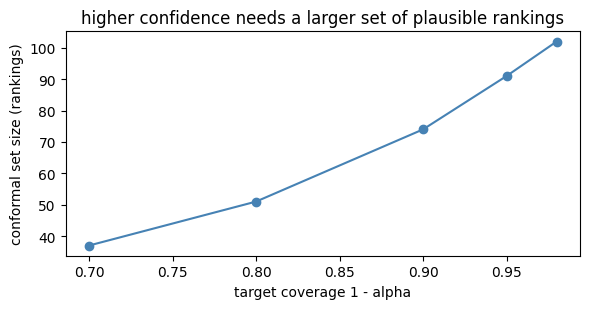

set size by target coverage: {0.7: 37, 0.8: 51, 0.9: 74, 0.95: 91, 0.98: 102}


In [3]:
# the set grows as the confidence level rises (alpha shrinks)
alphas = [0.3, 0.2, 0.1, 0.05, 0.02]
sizes = [ConformalStructure(pl, cal, alpha=a).size() for a in alphas]
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot([1 - a for a in alphas], sizes, 'o-', color='steelblue')
ax.set_xlabel('target coverage 1 - alpha'); ax.set_ylabel('conformal set size (rankings)')
ax.set_title('higher confidence needs a larger set of plausible rankings')
plt.tight_layout(); plt.show()
print('set size by target coverage:', dict(zip([round(1 - a, 2) for a in alphas], sizes)))

## 2. Transductive node classification

Fix a graph whose nodes carry class labels (communities, roles). In the transductive setting the labels
are revealed on a uniformly random subset of nodes; we fit a node classifier on part of that subset and
calibrate on the rest, then predict label sets for the unlabeled nodes. The random labeling makes the
node scores exchangeable, so the coverage theorem applies and `ConformalClassifier` (the same one used
for tabular classification) produces valid node-label sets from per-node class posteriors.

Here the node features come from the graph itself: we embed the adjacency matrix with its leading
eigenvectors (adjacency spectral embedding) and fit one Gaussian per class to get posteriors. Because
the procedure is model-agnostic, any node classifier that emits class probabilities would do.

In [4]:
from mixle.ppl import ConformalClassifier
from mixle.stats import MultivariateGaussianEstimator
from mixle.inference.estimation import optimize

rng = np.random.RandomState(0)
K, per = 3, 400; n = K * per
labels = np.repeat(range(K), per)
p_in, p_out = 0.07, 0.045                                   # weak communities -> the classifier is unsure at the edges
B = np.full((n, n), p_out)
for k in range(K):
    idx = np.where(labels == k)[0]; B[np.ix_(idx, idx)] = p_in
A = (rng.random((n, n)) < B).astype(float); A = np.triu(A, 1); A = A + A.T
w, V = np.linalg.eigh(A); top = np.argsort(w)[::-1][:K]
emb = V[:, top] * np.sqrt(np.abs(w[top]))                   # adjacency spectral embedding

perm = rng.permutation(n); tr, cal, te = perm[:n // 3], perm[n // 3:2 * n // 3], perm[2 * n // 3:]
comps = [optimize([list(emb[i]) for i in tr if labels[i] == k], MultivariateGaussianEstimator(dim=K),
                  max_its=1, rng=rng, print_iter=99999) for k in range(K)]
logpri = np.log(np.bincount(labels[tr], minlength=K) / len(tr))
def node_posteriors(nodes):
    Xl = [list(emb[i]) for i in nodes]
    ll = np.stack([c.seq_log_density(c.dist_to_encoder().seq_encode(Xl)) for c in comps], 1)
    z = ll + logpri; z -= z.max(1, keepdims=True); P = np.exp(z); return P / P.sum(1, keepdims=True)

cc = ConformalClassifier(node_posteriors(cal), labels[cal], alpha=0.1)
Pte = node_posteriors(te)
print('transductive node classification:')
print('  community-set coverage = %.3f (target 0.90)' % cc.covers(Pte, labels[te]).mean())
print('  mean set size = %.2f of %d communities;  top-1 accuracy = %.3f' %
      (cc.set_sizes(Pte).mean(), K, (Pte.argmax(1) == labels[te]).mean()))
print('  nodes the model is unsure about get 2-label sets; confident nodes get a single label.')

transductive node classification:
  community-set coverage = 0.895 (target 0.90)
  mean set size = 1.51 of 3 communities;  top-1 accuracy = 0.728
  nodes the model is unsure about get 2-label sets; confident nodes get a single label.


## 3. Link prediction

For a random-graph model the edge probability matrix $P$ scores every potential link. The nonconformity
of a present edge $(i,j)$ is $1-P[i,j]$; calibrating on a random half of the observed edges gives a
threshold, and `ConformalLinkPredictor` returns, for each node, the set of candidate neighbors with
$1-P[i,j]\le \tau$. That neighbor set contains a true neighbor with probability at least $1-\alpha$ over
the held-out edges. We take $P=XX^\top$ from latent positions, the random dot product graph model, but
any edge-probability matrix (Erdos-Renyi, stochastic block model) works.

In [5]:
from mixle.ppl import ConformalLinkPredictor

rng = np.random.RandomState(0)
n, d = 400, 2
X = np.abs(rng.normal(0, 1, (n, d))); X /= np.linalg.norm(X, axis=1, keepdims=True) * 1.6
P = np.clip(X @ X.T, 0, 1); np.fill_diagonal(P, 0.0)        # RDPG edge probabilities
A = (rng.random((n, n)) < P).astype(int); A = np.triu(A, 1); A = A + A.T
edges = np.argwhere(np.triu(A, 1) == 1); rng.shuffle(edges)
cut = len(edges) // 2
clp = ConformalLinkPredictor(P, edges[:cut], alpha=0.1)
print('link prediction (RDPG):')
print('  held-out edge coverage = %.3f (target 0.90)' % clp.covers(edges[cut:]).mean())
print('  mean neighbor-set size = %.0f of %d nodes (true mean degree = %.0f)' %
      (clp.set_sizes().mean(), n, A.sum(1).mean()))
print('  a denser / noisier graph needs larger neighbor sets to guarantee coverage.')

link prediction (RDPG):
  held-out edge coverage = 0.901 (target 0.90)
  mean neighbor-set size = 324 of 400 nodes (true mean degree = 126)
  a denser / noisier graph needs larger neighbor sets to guarantee coverage.


## 4. Knowledge-graph completion

A knowledge graph stores facts as triples $(h, r, t)$ -- head entity, relation, tail entity. Completion
asks, given $(h, r, ?)$, which tail entities are plausible. mixle models this with
`KnowledgeGraphDistribution`, a DistMult embedding model that lives in `mixle.stats.graph` and is fit by
the regular estimation framework: `optimize(triples, KnowledgeGraphEstimator(...))`, exactly like every
other distribution. Its `tail_log_posterior(h, r)` gives $\log p(t \mid h, r)$ over all entities (an
entity softmax of the bilinear score), so feeding $p(t \mid h, r)$ to `ConformalClassifier` yields a
calibrated set of tail entities that contains the true tail with probability at least $1-\alpha$, over a
random split of the observed triples. A good model gives a small set; a weak one a larger set with the
same guarantee.

In [6]:
from mixle.stats import KnowledgeGraphEstimator
from mixle.inference.estimation import optimize

rng = np.random.RandomState(0)
nE, nR, d = 60, 4, 12
ent_true = rng.normal(0, 1, (nE, d)); rel_true = rng.normal(0, 1, (nR, d))
def true_tail(h, r):
    return int(np.argmax(ent_true @ (ent_true[h] * rel_true[r])))           # DistMult-generated facts
triples = [(int(h), int(r), true_tail(int(h), int(r))) for h, r in
           zip(rng.randint(nE, size=6000), rng.randint(nR, size=6000))]

# fit the knowledge graph with mixle's regular estimation framework
kg = optimize(triples, KnowledgeGraphEstimator(nE, nR, dim=d, seed=1), max_its=1, rng=rng, print_iter=99999)

def tail_posteriors(queries):
    return np.array([np.exp(kg.tail_log_posterior(h, r)) for h, r in queries])

queries = [(h, r) for h, r, t in triples]; tails = np.array([t for h, r, t in triples])
cc = ConformalClassifier(tail_posteriors(queries[:2000]), tails[:2000], alpha=0.1)
Pte = tail_posteriors(queries[2000:4000]); yte = tails[2000:4000]
print('knowledge-graph completion (h, r, ?):')
print('  tail-set coverage = %.3f (target 0.90)' % cc.covers(Pte, yte).mean())
print('  mean tail-set size = %.1f of %d entities;  top-1 accuracy = %.3f' %
      (cc.set_sizes(Pte).mean(), nE, (Pte.argmax(1) == yte).mean()))
print('  the calibrated set narrows the candidate tails from 60 to a handful while keeping coverage.')

knowledge-graph completion (h, r, ?):
  tail-set coverage = 0.895 (target 0.90)
  mean tail-set size = 2.6 of 60 entities;  top-1 accuracy = 0.632
  the calibrated set narrows the candidate tails from 60 to a handful while keeping coverage.


## In short

- Conformal prediction gives set-valued uncertainty with a finite-sample coverage guarantee that needs
  only exchangeability of the nonconformity scores, never a correct model.
- On graphs the design must secure that exchangeability: iid structures, a random node labeling
  (transductive), or a random edge / triple split. Under those splits the same machinery applies.
- mixle supplies the pieces: `ConformalStructure` for combinatorial objects, `ConformalClassifier`
  for node-label and knowledge-graph-tail sets, and `ConformalLinkPredictor` for edges, all on top of
  its exact structure densities, spectral embeddings, random-graph models, and the TransE knowledge-graph
  model.
- Set size is the honest read-out of confidence: a sharp model yields small sets, a weak one larger sets,
  and coverage holds either way.

## References

- Vovk, V., Gammerman, A. & Shafer, G. (2005). Algorithmic Learning in a Random World. Springer.
- Angelopoulos, A. & Bates, S. (2023). Conformal prediction: a gentle introduction. Foundations and Trends in Machine Learning. https://arxiv.org/abs/2107.07511
- Zargarbashi, S. H., Antonelli, S. & Bojchevski, A. (2023). Conformal prediction sets for graph neural networks. ICML.
- Huang, K., Jin, Y., Candes, E. & Leskovec, J. (2023). Uncertainty quantification over graph with conformalized graph neural networks. NeurIPS.
- Bordes, A., Usunier, N., Garcia-Duran, A., Weston, J. & Yakhnenko, O. (2013). Translating embeddings for modeling multi-relational data (TransE). NeurIPS.
- Sutton, C. & Reich, B. (2023). Conformal link prediction. (link-prediction conformal sets.)

## Exercises and extensions

1. Conditional coverage on graphs. Marginal coverage can hide uneven coverage across node degrees or
   communities. Stratify the node-classification coverage by degree quartile and by true community, find
   where it sags, and build a Mondrian (group-conditional) conformal predictor that calibrates separately
   within each stratum. Quantify the trade-off between conditional coverage and set size.
2. Adaptive prediction sets. Replace the $1-p(\text{true})$ score with the adaptive APS score (the
   cumulative probability of all labels at least as likely as the true one; Romano, Sesia, Candes 2020)
   for the node and knowledge-graph tasks, and compare set sizes at matched coverage.
3. Distribution shift breaks exchangeability. Sample calibration nodes from two communities and test
   nodes from the third, or calibrate on triples of one relation and test on another, and measure how far
   coverage falls. Then restore validity with weighted conformal prediction using estimated likelihood
   ratios.
4. Structure sets at scale. For Mallows and Plackett-Luce with larger item sets the exact enumerator
   becomes expensive. Use the model's sampler to estimate the conformal set size by Monte Carlo, and to
   draw a representative member set, without full enumeration. Compare to the exact count on a small
   instance.
5. Calibrating an unsupervised block model. Fit `StochasticBlockGraphDistribution` and use its node
   community posteriors directly (handling label switching) as the conformal scores. Compare the coverage
   and set sizes to the spectral-embedding classifier used here.